## AnalystLab Africa Internship
### Week 1 Data Cleaning and Exploratory Data Analysis (EDA)
### E-Commerce Dataset


In [9]:
#importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [10]:
# Loading the Netflix dataset
import pandas as pd 
OnlineRetail = pd.read_csv("OnlineRetail.csv", encoding="latin1")
# Shows the first 5 rows in the table
OnlineRetail.head
# Displaying column names 
OnlineRetail.columns
# Displaying information about the dataset 
OnlineRetail.info()
# Generating summary statistics for the dataset
OnlineRetail.describe(include="all")
# Checking for Duplicates 
OnlineRetail.duplicated().sum()
# Removing duplicates
OnlineRetail = OnlineRetail.drop_duplicates()
# Checking for missing values
OnlineRetail.isnull().sum()
# Eemove missing Customer ID
OnlineRetail = OnlineRetail.dropna(subset=["CustomerID"])
# Remove negative quantities
OnlineRetail = OnlineRetail[OnlineRetail["Quantity"] > 0]
# Remove negative price
OnlineRetail = OnlineRetail[OnlineRetail["UnitPrice"] > 0]
# Convert date to date time
OnlineRetail["InvoiceDate"] = pd.to_datetime(OnlineRetail["InvoiceDate"])
# Exploratory Data Analytics
OnlineRetail["TotalSales"] = OnlineRetail["Quantity"] * OnlineRetail["UnitPrice"]
OnlineRetail.head()
# Save cleaned dataset
OnlineRetail.to_csv("OnlineRetail_cleaned.csv", index=False)


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


# Data Preparation

## Data Exploration, Cleaning, Feature Engineering, and Export

Before performing any analysis, the dataset was carefully examined to understand its structure and identify potential data quality issues. This involved reviewing the dataset's dimensions, data types, missing values, and summary statistics to gain a clear understanding of the data.

Following the initial exploration, the dataset was cleaned to improve its quality and reliability. Duplicate records were removed, missing values were handled appropriately, and the `InvoiceDate` column was converted to a datetime format to enable time-based analysis. Invalid records, where applicable, were also addressed to ensure the dataset accurately represented completed sales transactions.

To enrich the analysis, additional features were created. A new column named **TotalSales** was generated by multiplying the `Quantity` and `UnitPrice` columns, providing the revenue for each transaction. A **Month** column was also extracted from the `InvoiceDate` field to facilitate monthly sales trend analysis and identify seasonal patterns.

After completing the preparation process, the cleaned dataset was exported as a new CSV file (`OnlineRetail_Cleaned.csv`). Saving a cleaned version of the dataset ensures consistency, improves reproducibility, and allows the prepared data to be used directly for exploratory data analysis and Power BI dashboard development without repeating the cleaning process.

# Exploratory Data Analysis (EDA)

In this section, we explore the cleaned Online Retail dataset to uncover trends, customer behavior, product performance, and sales patterns. The insights generated will help inform business decisions.

In [11]:
#Exploratory Data Analytics 
## Total Revenue
OnlineRetail["TotalSales"].sum()
## Total Numbeer of Transactions
OnlineRetail["InvoiceNo"].nunique()
## Total Number of Customers 
OnlineRetail["CustomerID"].nunique()
## Total Number of Products
OnlineRetail["StockCode"].nunique()
# Total Quantity Sold
OnlineRetail["Quantity"].sum()


np.int64(5152002)

## Total Revenue
This analysis calculates the total revenue generated from all completed transactions in the dataset.

## Total Number of Transactions
This analysis determines the total number of unique invoices processed.

## Total Number of Customers
This analysis identifies the total number of unique customers who made purchases.

## Total Number of Products
This analysis identifies the total number of unique products.

## Total Quantity Sold
This analysis shows the total quantity of goods sold.

## Top 10 Countries by Revenue

This analysis identifies the countries generating the highest sales revenue.

<function matplotlib.pyplot.show(close=None, block=None)>

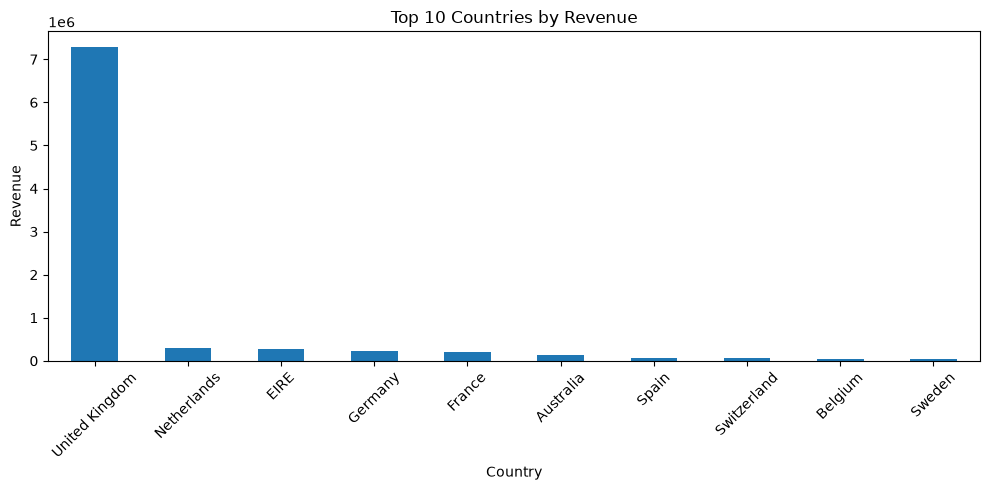

In [12]:
# Top 10 Countries by Revenue
Country_Sales = OnlineRetail.groupby("Country") ["TotalSales"].sum().sort_values(ascending=False)
Country_Sales.head(10)

## Visualization
import matplotlib.pyplot as plt

Country_Sales.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show

### Interpretation

The countries with the highest revenue represent the company's strongest markets.

## Top 10 Best-Selling Products

This analysis identifies the products with the highest quantities sold.

<function matplotlib.pyplot.show(close=None, block=None)>

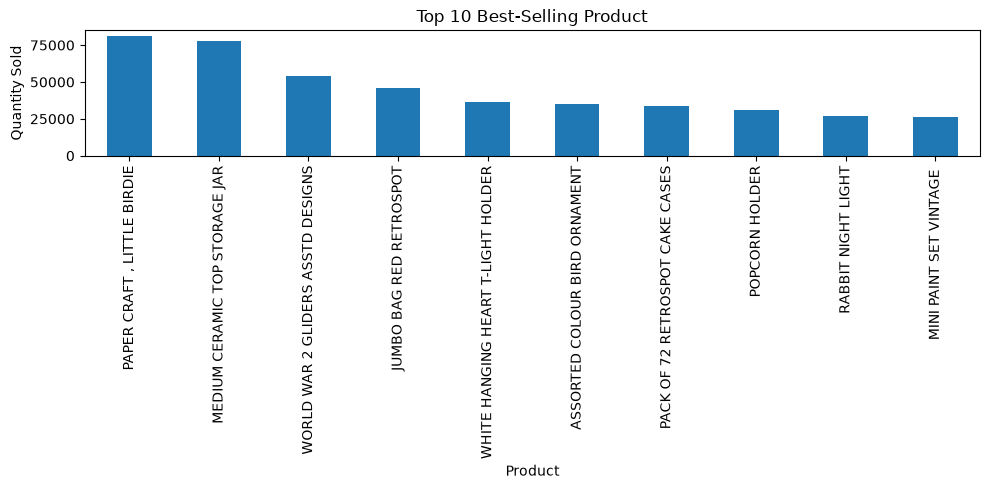

In [13]:
# Top 10 Best-Selling Product
top_products = OnlineRetail.groupby("Description") ["Quantity"].sum().sort_values(ascending=False)
top_products.head(10)

## Visualization
top_products.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Best-Selling Product")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show


### Interpretation

The best-selling products have the highest customer demand and should receive priority in inventory planning.

## Monthly Sales Trend

This analysis examines how revenue changes over time on a monthly basis.

<function matplotlib.pyplot.show(close=None, block=None)>

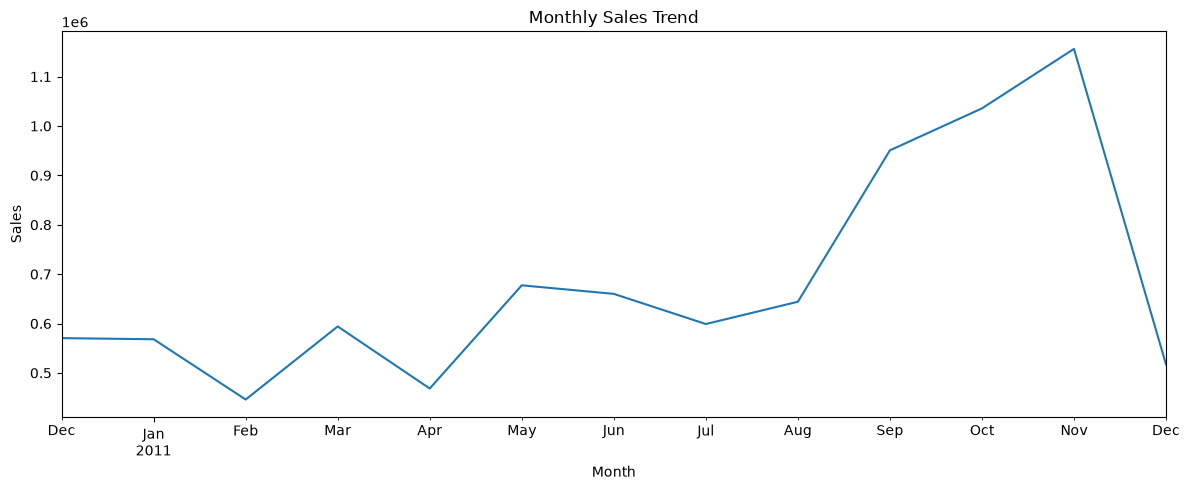

In [14]:
OnlineRetail["Month"] = OnlineRetail["InvoiceDate"].dt.to_period("M")
monthly_sales = OnlineRetail.groupby("Month") ["TotalSales"].sum()

monthly_sales

## Visualization
monthly_sales.plot(figsize=(12,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()
plt.show

### Interpretation

The monthly sales trend highlights seasonal patterns, growth periods, and months with lower sales performance.

## Top 10 Products by Revenue

This analysis identifies the products that generated the highest revenue.

<function matplotlib.pyplot.show(close=None, block=None)>

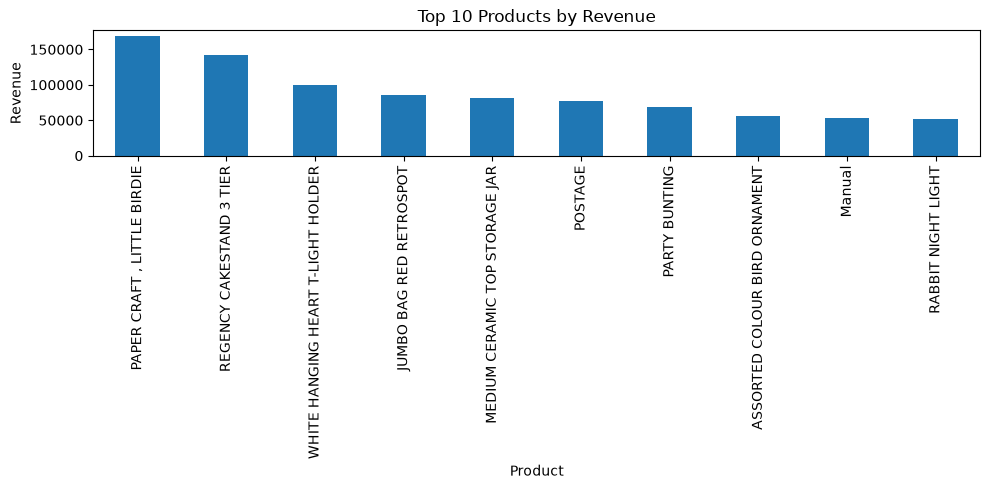

In [15]:
# Top 10 Products by Revenue 
product_revenue = OnlineRetail.groupby("Description") ["TotalSales"].sum().sort_values(ascending=False)
product_revenue.head(10)

## Visualization
product_revenue.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show

### Interpretation

Paper Craft Little Birdie generates the highest revenue and play a major role in the company's financial performance.

## Top 10 Customers by Revenue

This analysis identifies the customers who generated the most revenue.

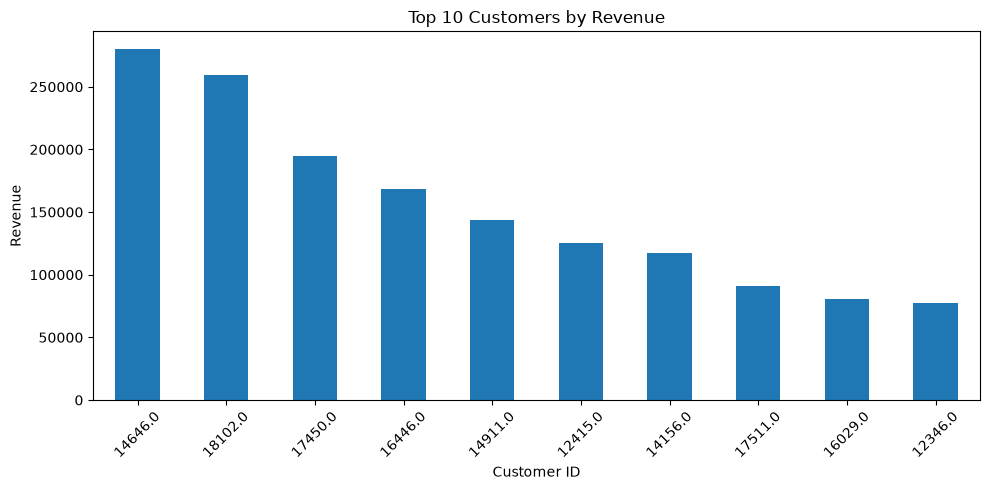

In [16]:
top_customers = OnlineRetail.groupby("CustomerID")["TotalSales"].sum().sort_values(ascending=False)
top_customers.head(10)

top_customers.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation

The top customers contribute a significant portion of total revenue and are valuable for customer retention strategies.